# analyzing audio features for trinidad dancehall tracks  

### motivation  

I really like dancehall generally, as well as hip-hop/rap.  

these two genres have similar "sounds" but are also similar thematically. assuming that the US market / music industry is where global stardom is to be found, I started wondering if the US market has the appetite for dancehall to be popular, and if so, what types of songs are more likely to blow up over there. 

### overall goal + methodology  

the goal behind this project is to investigate the audio features of trinidad dancehall (trinibad) songs to predict how popular a given song would be in the US market.

the main methodology is to:

1. **train a model on** audio features of **popular hip-hop tracks** - *this creates a distribution assumption on popular tracks within the US market.*
2. **score trinidad dancehall tracks** using the above model - *this gives a rough measure of where these songs lie on the US market distribution.*


### a note on the datasets  

these datasets were generated using the ETL pipeline from this repo - [song-feature-extraction](https://github.com/rparmasar/song-feature-extraction).

the high-level strategy for fetching this data looked like:

1. identify popular playlists for hip-hop and trinidad dancehall songs

2. grab their playlist ids and pass these into the ETL pipeline  

the ETL pipeline then handles fetching the audio features + response (`popularity`) for each track in each playlist and returns a `csv` indexed by track id.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statistics import mean
from typing import Callable

from src.visualization.predictions import plot_train_test_dist

## initial EDA for popular hip-hop tracks  

here, we'll do a quick check of the modelling dataset.  

### notes on findings  

* pretty decent sized dataset with 2255 rows with no missing values for audio feature columns or `popularity` column

* most of the tracks seem to have higher danceability & energy since the mean and median seem quite close however, this may be as a property of the hip-hop/rap genre itself.

* anectodally, many dancehall songs are also upbeat and lively so this aligns with what our dataset shows (i.e. the similarity in "sound" between the genres)

In [2]:
track_df = pd.read_csv(filepath_or_buffer="./data/hip_hop-track-attributes.csv", index_col="track_id")
track_df.head()

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,...,track_source_playlist,track_artists_id,track_artists_name,track_artists_followers,track_artists_genres,track_artists_popularity,release_date,release_date_precision,popularity,generated_timestamp
track_id,,,,,,,,,,,,,,,,,,,,,
7y911sqgHGHcyU4ivapjwi,0.670,0.515,1,-6.977,1,0.3970,0.0705,0.000000,0.250,0.422,...,62y3BHKehWnb1hlaPclDAA,"3TVXtAsR1Inumwj472S9r4,17lzZA2AlOHwCwFALHttmp,...",Drake|2 Chainz|Big Sean,83626299|8017349|11115824,canadian hip hop|canadian pop|hip hop|pop rap|...,96|75|75,2013-01-01,day,67,2024-01-08
0Thqjtu54vKMP06pwZkAWp,0.889,0.400,4,-10.586,0,0.2600,0.3220,0.000013,0.331,0.336,...,62y3BHKehWnb1hlaPclDAA,6l3HvQ5sa6mXTsMTB19rO5,J. Cole,22394288,conscious hip hop|hip hop|north carolina hip h...,86,2014-12-09,day,75,2024-01-08
6mapJIPnQ23RTAevUoE0DL,0.681,0.314,8,-9.319,1,0.0581,0.2000,0.000010,0.100,0.166,...,62y3BHKehWnb1hlaPclDAA,7iZtZyCzp3LItcw1wtPI3D,Rae Sremmurd,7361248,melodic rap|mississippi hip hop|pop rap|rap|trap,71,2016-08-12,day,77,2024-01-08
6j9iyrrmqWlQZ5SD1hSTaq,0.634,0.665,6,-5.984,0,0.1760,0.0172,0.000000,0.365,0.611,...,62y3BHKehWnb1hlaPclDAA,"17lzZA2AlOHwCwFALHttmp,3TVXtAsR1Inumwj472S9r4",2 Chainz|Drake,8017349|83626299,atl hip hop|hip hop|pop rap|rap|southern hip h...,75|96,2012-01-01,day,62,2024-01-08
6Nw1WHydftZy2joT2nTiCR,0.793,0.498,8,-11.208,0,0.1700,0.0974,0.000013,0.130,0.427,...,62y3BHKehWnb1hlaPclDAA,"6l3HvQ5sa6mXTsMTB19rO5,2wIVse2owClT7go1WT98tk",J. Cole|Missy Elliott,22394288|2364592,conscious hip hop|hip hop|north carolina hip h...,86|70,2011-09-27,day,69,2024-01-08


In [3]:
track_df.describe()

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,popularity
count,2255.000000,2255.000000,2255.000000,2255.000000,2255.000000,2255.000000,2255.000000,2255.000000,2255.00000,2255.000000,2255.000000,2255.000000,2255.000000,2255.000000
mean,0.736051,0.628322,5.180488,-6.613969,0.545455,0.205009,0.145934,0.004542,0.19231,0.457821,125.213459,210517.955654,3.991131,63.478492
std,0.133991,0.142861,3.743764,2.241772,0.498040,0.134446,0.173296,0.046179,0.14283,0.218088,28.160498,53800.725278,0.285577,16.906480
min,0.231000,0.161000,0.000000,-18.121000,0.000000,0.026900,0.000034,0.000000,0.02860,0.035200,60.034000,72072.000000,1.000000,0.000000
25%,0.657000,0.528000,1.000000,-7.877000,0.000000,0.082100,0.023250,0.000000,0.10300,0.284000,100.013500,173593.500000,4.000000,56.000000
50%,0.755000,0.628000,5.000000,-6.337000,1.000000,0.184000,0.075900,0.000000,0.13400,0.452000,128.090000,208929.000000,4.000000,67.000000
75%,0.836000,0.722000,8.000000,-5.104000,1.000000,0.305000,0.203000,0.000002,0.24300,0.619000,144.947000,239624.000000,4.000000,75.000000
max,0.978000,0.978000,11.000000,-1.218000,1.000000,0.902000,0.967000,0.954000,0.87700,0.966000,209.763000,547733.000000,5.000000,96.000000


In [4]:
track_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2255 entries, 7y911sqgHGHcyU4ivapjwi to 1gqkRc9WtOpnGIqxf2Hvzr
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   danceability              2255 non-null   float64
 1   energy                    2255 non-null   float64
 2   key                       2255 non-null   int64  
 3   loudness                  2255 non-null   float64
 4   mode                      2255 non-null   int64  
 5   speechiness               2255 non-null   float64
 6   acousticness              2255 non-null   float64
 7   instrumentalness          2255 non-null   float64
 8   liveness                  2255 non-null   float64
 9   valence                   2255 non-null   float64
 10  tempo                     2255 non-null   float64
 11  duration_ms               2255 non-null   int64  
 12  time_signature            2255 non-null   int64  
 13  track_name                225

## response EDA

### context on `popularity` definition  

here, we're interested in predicting the `popularity` of a track.  

`popularity` takes on values between `[0, 100]` and measures how popular tracks are. there is also a time component to it in that tracks with more plays recently will be **more** popular than tracks with the same number of plays in the past.  

see more on [the docs here](https://developer.spotify.com/documentation/web-api/reference/get-track)

### notes on the response distribution  

the histogram & boxplot show that most songs lie within the [55, 80] range with a small group occupying the [0, 10] range.  

this checks out since the response info was fetched from popular playlists and so more popular songs (`> 50`) are more likely to be represented with the [0, 10] group potentially representing the creator's favourite tracks or tracks that were popular historically but fallen off at the time of data fetching.  

based on the distribution & assuming `popularity` as a count-type variable, we can start with a Poisson GLM as an initial model.



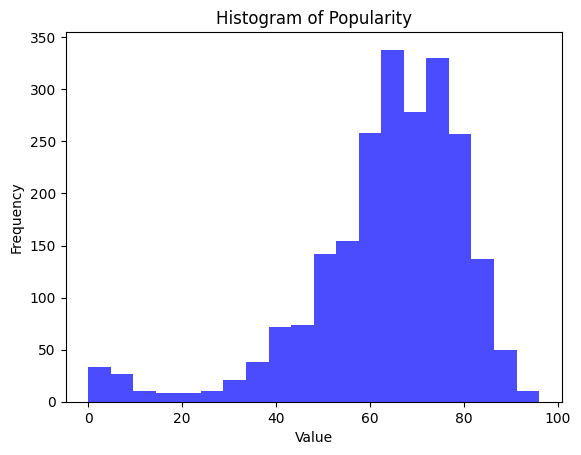

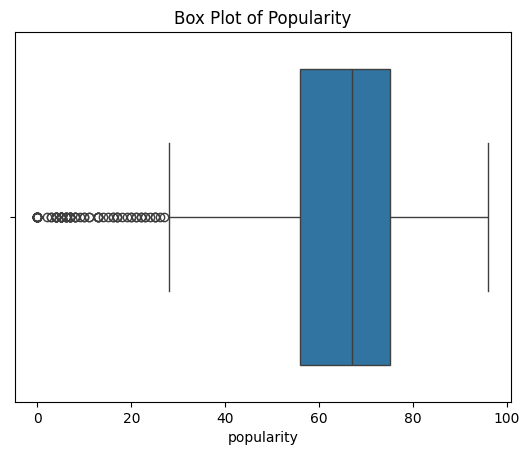

In [5]:
# Plot a histogram for a numerical variable
plt.hist(track_df['popularity'], bins=20, color='blue', alpha=0.7)
plt.title('Histogram of Popularity')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

# Box plot to visualize the distribution and identify outliers
sns.boxplot(x=track_df['popularity'])
plt.title('Box Plot of Popularity')
plt.show()


### response and audio features  

we'll also take a look at how `popularity` varies with each numerical audio feature.  

here are some notes,

* scatterplots for `danceability`, `energy`, `loudness` & `speechiness` show that popular tracks tend to cluster in tighter ranges however, there is clearly some sort of non-linear relationship here.

* `key` shows no obvious trends as popularity seems well represented across each key *(lines are because these are integers that map using [pitch class notation](https://en.wikipedia.org/wiki/Pitch_class))*

* `instrumentalness` is almost all 0 but this makes sense as the docs define this variable as as being close to 0 for rap/spoken word tracks (due to the heavy lyrical content)  

* more popular tracks are clustered around lower `liveness` *(likelihood of the track being performed with an audience)* however, this could be due to the playlists containing minimal live performance tracks.  

* `time_signature` has a similar intepretation as `key`  

* `valence` *(measure of how positive the track sounds)* and `tempo` also don't show any obvious trends as the plots are relatively dispersed.

* the linear correlation heatmap (using Pearson coefficients) shows slight relationships between `speechiness` and `loudness` with `popularity` in that `speechiness` is negatively correlated while `loudness` is positively correlated.  

* `loudness` and `speechiness` also seem to show a negative linear correlation while `energy`, `liveness`, and `valence` show a positive linear correlation (likely due to `energy` being defined as a function of those 2 with some extra proprietry features).

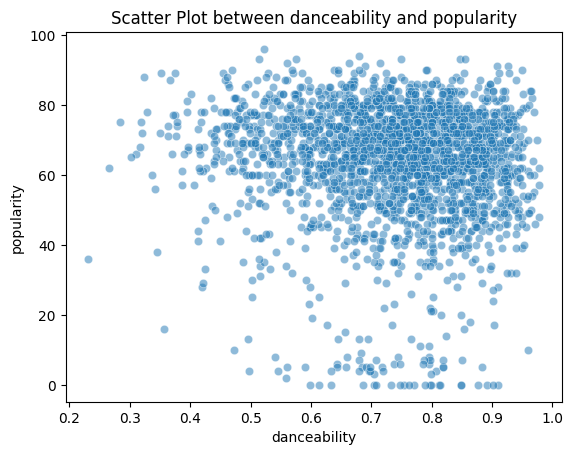

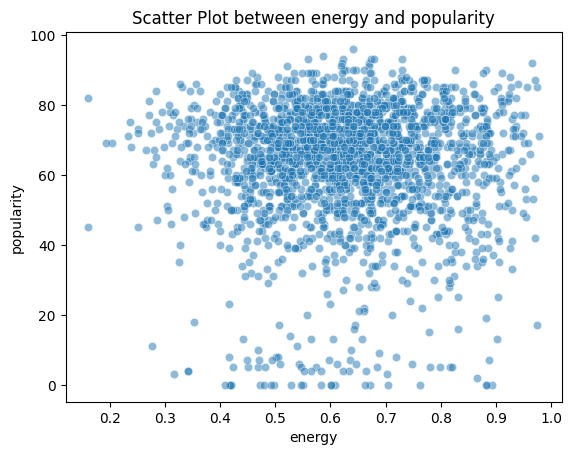

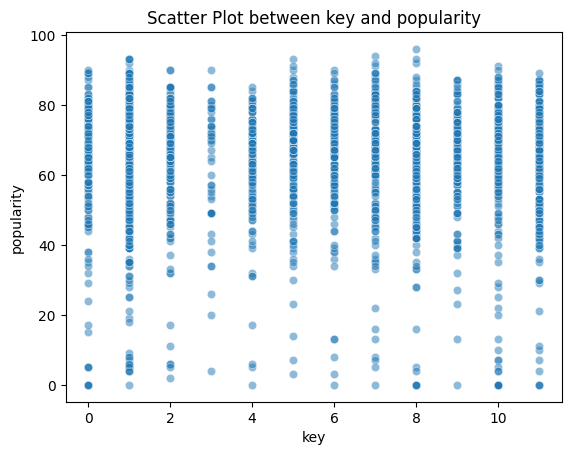

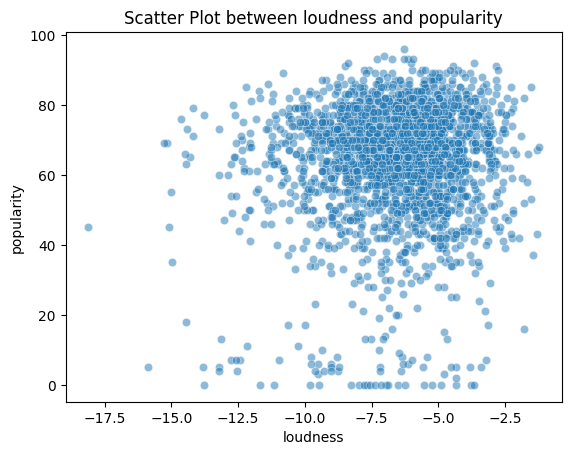

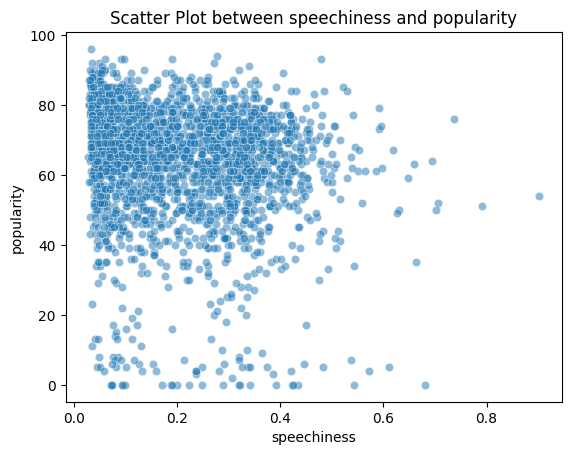

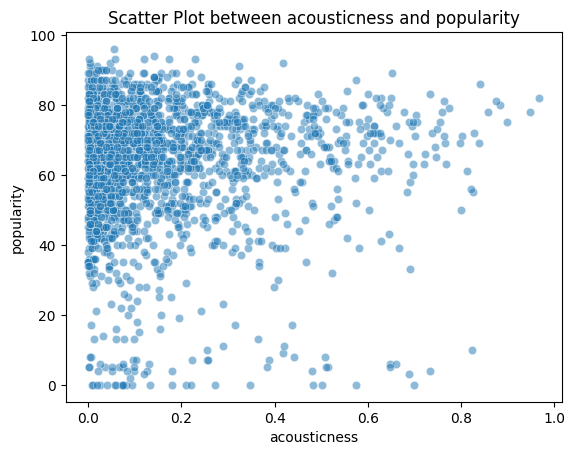

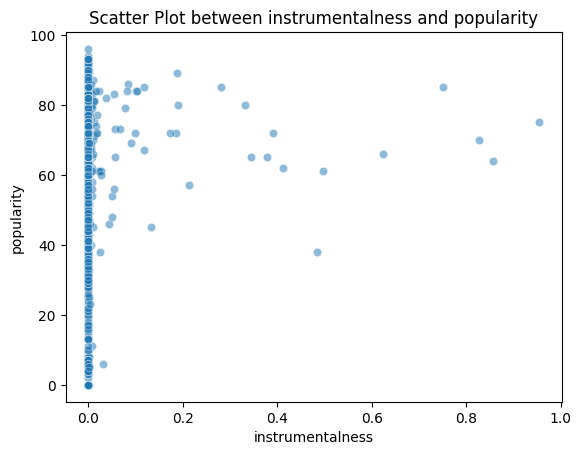

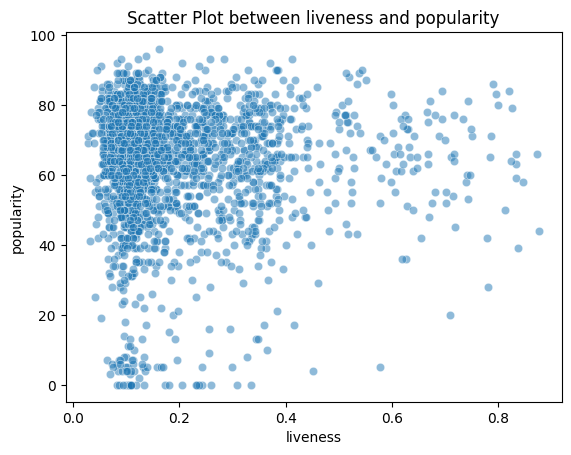

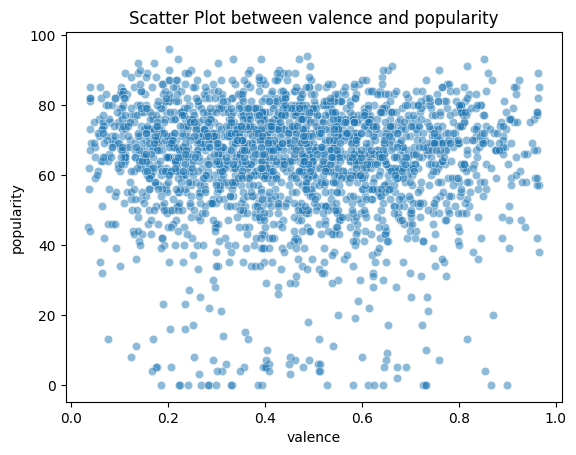

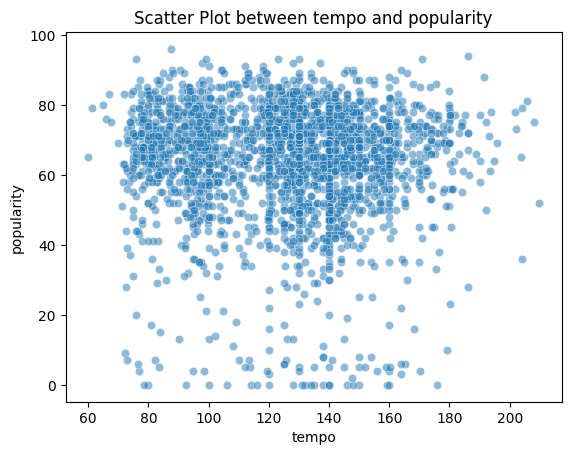

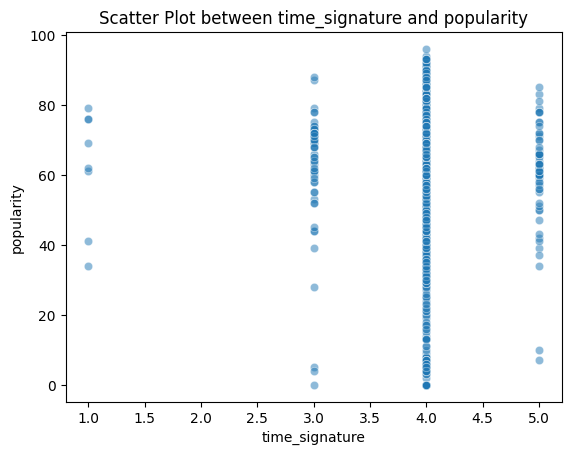

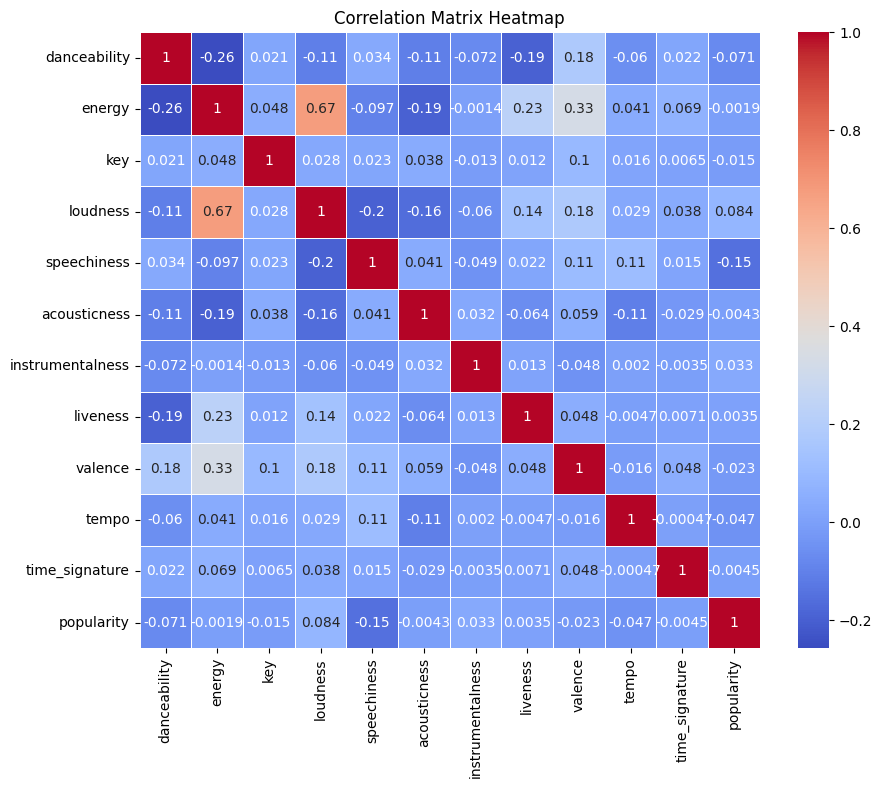

In [4]:
target_numerical_features = [
    'danceability',
    'energy',
    'key',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo',
    'time_signature',
]

for feature in target_numerical_features:
    feature_arr = track_df[feature]
    response_arr = track_df['popularity']
    playlist_id_arr = track_df['track_source_playlist']

    sns.scatterplot(
        x=feature_arr,
        y=response_arr,
        alpha=0.5
        # hue=playlist_id_arr
    )
    plt.title(f'Scatter Plot between {feature} and popularity')
    plt.xlabel(feature)
    plt.ylabel('popularity')
    plt.show()

corr_cols = [*target_numerical_features, 'popularity']

track_df_subset = track_df[corr_cols]
corr_matrix = track_df_subset.corr()

# Create a heatmap using Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()


In [8]:
track_df.columns

Index(['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
       'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
       'duration_ms', 'time_signature', 'track_name', 'track_source_playlist',
       'track_artists_id', 'track_artists_name', 'track_artists_followers',
       'track_artists_genres', 'track_artists_popularity', 'release_date',
       'release_date_precision', 'popularity', 'generated_timestamp'],
      dtype='object')

## Modelling  

The approach here invovles training a model to predict `popularity` given a track's attributes and then using that model to score dancehall tracks. The motivation comes from trying to see how popular dancehall tracks would be assuming they had the large reach that the hip hop track have.

### Dataset Pre-Processing  

#### Handling Multiple Artist Attributes  

Since tracks can have multiple artists, we'll try to aggregate the artist attributes (`track_artists_followers`, `track_artists_popularity`) in a few ways:  

- `max_aggr`: Take the maximum popularity and followers of all artists involved in a track (This assumes that the smaller artist will reach all of the biggest artist's fans)  
- `mean_aggr`: Take the average popularity and followers of all artists involved in a track

We'll also create a column called `main_artist` which takes the first artist name since in song titles, the featured artists are usually listed after the main artist.

#### Handling `release_date` Metrics  

From the Spotify API docs, `release_date_precision` can be either `"year"`, `"month"`, or `"day"` so we'll need to handle those differently to compute additional features.  

Some options to try here are:  

- `release_year`: Keeps track of the year of release
- `time_since_release`: Keeps track of the time diff between `release_date` and `generated_timestamp` in days

In [9]:
def get_main_artist(artist_names: "list[str]") -> str:
    return artist_names.split("|")[0]

def condense_artist_attributes(artist_attrs: "list[str]", summ_func: Callable) -> "int":
    """
    Can pass `summ_func = max` for `max_aggr` or `summ_func = mean` for `mean_aggr`
    """
    proper_type_lst = [int(attr) for attr in artist_attrs.split("|")]
    agg_val = summ_func(proper_type_lst)

    return agg_val if isinstance(agg_val, int) else int(round(agg_val))

def get_release_year(date_str: str) -> int:
    """
    Given that dates are at most in YYYY-MM-DD format, we split by "-" and return the first value
    """
    return date_str.split("-")[0]

#### Applying Transforms

In [10]:
# Copying to avoid changing the original dataset
modelling_df = track_df.copy()

## Add main_artist (replace $ with S to avoid errors)
modelling_df.loc[:, "main_artist"] = modelling_df["track_artists_name"].apply(get_main_artist)
modelling_df["main_artist"] = modelling_df["main_artist"].str.replace('\$','S', regex=True)

## Add release_year
modelling_df.loc[:, "release_year"] = modelling_df["release_date"].apply(get_release_year)

## Add max_aggr attributes
modelling_df.loc[:, "max_aggr_popularity"] = modelling_df["track_artists_popularity"].apply(lambda val: condense_artist_attributes(val, max))
modelling_df.loc[:, "max_aggr_followers"] = modelling_df["track_artists_followers"].apply(lambda val: condense_artist_attributes(val, max))

## Add mean_aggr attributes
modelling_df.loc[:, "mean_aggr_popularity"] = modelling_df["track_artists_popularity"].apply(lambda val: condense_artist_attributes(val, mean))
modelling_df.loc[:, "mean_aggr_followers"] = modelling_df["track_artists_followers"].apply(lambda val: condense_artist_attributes(val, mean))

### Initial Modelling Dataset

In [39]:
target_features = [
    'danceability',
    'mode',
    'energy',
    'key',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo',
    'time_signature',
    'duration_ms',
    # 'main_artist',
    # 'release_year',
    # 'max_aggr_popularity',
    # 'max_aggr_followers',
    # 'mean_aggr_popularity',
    # 'mean_aggr_followers',
]

target_response = 'popularity'

feature_dtype_map = {
    'mode': 'category',
    'key': 'category',
    # 'main_artist': 'category',
    # 'release_year': 'int64',
}

subset_cols = [*target_features, target_response]

modelling_df = modelling_df[subset_cols]
modelling_df = modelling_df.astype(feature_dtype_map)
modelling_df.head()

,danceability,mode,energy,key,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,duration_ms,popularity
track_id,,,,,,,,,,,,,,
7y911sqgHGHcyU4ivapjwi,0.670,1,0.515,1,-6.977,0.3970,0.0705,0.000000,0.250,0.422,122.006,4,270867,67
0Thqjtu54vKMP06pwZkAWp,0.889,0,0.400,4,-10.586,0.2600,0.3220,0.000013,0.331,0.336,128.073,4,301064,75
6mapJIPnQ23RTAevUoE0DL,0.681,1,0.314,8,-9.319,0.0581,0.2000,0.000010,0.100,0.166,139.992,4,208120,77
6j9iyrrmqWlQZ5SD1hSTaq,0.634,0,0.665,6,-5.984,0.1760,0.0172,0.000000,0.365,0.611,131.108,4,237827,62
6Nw1WHydftZy2joT2nTiCR,0.793,0,0.498,8,-11.208,0.1700,0.0974,0.000013,0.130,0.427,119.988,4,190653,69


In [12]:
modelling_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2255 entries, 7y911sqgHGHcyU4ivapjwi to 1gqkRc9WtOpnGIqxf2Hvzr
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   danceability         2255 non-null   float64 
 1   mode                 2255 non-null   category
 2   energy               2255 non-null   float64 
 3   key                  2255 non-null   category
 4   loudness             2255 non-null   float64 
 5   speechiness          2255 non-null   float64 
 6   acousticness         2255 non-null   float64 
 7   instrumentalness     2255 non-null   float64 
 8   liveness             2255 non-null   float64 
 9   valence              2255 non-null   float64 
 10  tempo                2255 non-null   float64 
 11  time_signature       2255 non-null   int64   
 12  duration_ms          2255 non-null   int64   
 13  release_year         2255 non-null   int64   
 14  mean_aggr_followers  2255 non-null   i

### Model Fitting  

#### Train Test Split & Scaling

We'll create a holdout set with 25% of the data and also scale the predictors using a `MinMaxScaler()`

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler

# Create dummy cols for categorical features
modelling_features = pd.get_dummies(modelling_df.drop("popularity", axis=1))
modelling_response = modelling_df[["popularity"]]

train_features, test_features, train_response, test_response = train_test_split(
    modelling_features,
    modelling_response,
    test_size=0.25,
    random_state=25
)

print(f"Training Features Shape: {train_features.shape}")
print(f"Training Response Shape: {train_response.shape}")
print(f"Test Features Shape: {test_features.shape}")
print(f"Test Response Shape: {test_response.shape}")

# Scale Train Features
mm_scaler = MinMaxScaler()
train_features_scaled = mm_scaler.fit_transform(train_features)

## Scale test features
test_features_scaled = mm_scaler.transform(test_features)

Training Features Shape: (1691, 25)
Training Response Shape: (1691, 1)
Test Features Shape: (564, 25)
Test Response Shape: (564, 1)


#### Cross-Validation on Initial Model Candidates  

We'll try a few different models and rank them in order of predictive performance (using `root mean squared error`) using a 5-fold cross-validation scheme.

##### ElasticNet

In [14]:
from sklearn.model_selection import GridSearchCV

In [15]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import PoissonRegressor, ElasticNet

LINEAR_CANDIDATE_MODELS_MAP = {
    'elastic_net_linear_regression': ElasticNet,
    'poission_glm_regression': PoissonRegressor,
}

# For storing results later on
CANDIDATE_MODELS_SCORES = {}

# Grid search params
en_grid_search_params = {
    'alpha': np.linspace(start=0.1, stop=1, num=50),
    'l1_ratio': np.linspace(start=0.1, stop=1, num=50),
}

# Initialize ElasticNet Cross Validation
elastic_net_grid_search = GridSearchCV(
    estimator=LINEAR_CANDIDATE_MODELS_MAP['elastic_net_linear_regression'](),
    param_grid=en_grid_search_params,
    scoring='neg_root_mean_squared_error',
    cv=5,
    verbose=2
)

# Fit Models
elastic_net_grid_search.fit(X=train_features_scaled, y=train_response)

Fitting 5 folds for each of 2500 candidates, totalling 12500 fits
[CV] END ............................alpha=0.1, l1_ratio=0.1; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.1; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.1; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.1; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.1; total time=   0.0s
[CV] END ............alpha=0.1, l1_ratio=0.11836734693877551; total time=   0.0s
[CV] END ............alpha=0.1, l1_ratio=0.11836734693877551; total time=   0.0s
[CV] END ............alpha=0.1, l1_ratio=0.11836734693877551; total time=   0.0s
[CV] END ............alpha=0.1, l1_ratio=0.11836734693877551; total time=   0.0s
[CV] END ............alpha=0.1, l1_ratio=0.11836734693877551; total time=   0.0s
[CV] END ............alpha=0.1, l1_ratio=0.13673469387755102; total time=   0.0s
[CV] END ............alpha=0.1, l1_ratio=0.

GridSearchCV(cv=5, estimator=ElasticNet(),
             param_grid={'alpha': array([0.1       , 0.11836735, 0.13673469, 0.15510204, 0.17346939,
       0.19183673, 0.21020408, 0.22857143, 0.24693878, 0.26530612,
       0.28367347, 0.30204082, 0.32040816, 0.33877551, 0.35714286,
       0.3755102 , 0.39387755, 0.4122449 , 0.43061224, 0.44897959,
       0.46734694, 0.48571429, 0.50408163, 0.52244898, 0.54081633,
       0.55918367, 0.577...
       0.46734694, 0.48571429, 0.50408163, 0.52244898, 0.54081633,
       0.55918367, 0.57755102, 0.59591837, 0.61428571, 0.63265306,
       0.65102041, 0.66938776, 0.6877551 , 0.70612245, 0.7244898 ,
       0.74285714, 0.76122449, 0.77959184, 0.79795918, 0.81632653,
       0.83469388, 0.85306122, 0.87142857, 0.88979592, 0.90816327,
       0.92653061, 0.94489796, 0.96326531, 0.98163265, 1.        ])},
             scoring='neg_root_mean_squared_error', verbose=2)

In [16]:
# Display results
print(f"Best Parameters: {elastic_net_grid_search.best_params_}")
print(f"Best CV Score: {-elastic_net_grid_search.best_score_}")
# print(pd.DataFrame(elastic_net_grid_search.cv_results_))

# Best Estimator
elastic_net_best_estimator = elastic_net_grid_search.best_estimator_
elastic_net_coefs_df = pd.DataFrame({
    'feature_name': train_features.columns,
    'coefficent_value': elastic_net_best_estimator.coef_
})

print(elastic_net_coefs_df)

Best Parameters: {'alpha': 0.1, 'l1_ratio': 1.0}
Best CV Score: 15.959485062235775
           feature_name  coefficent_value
0          danceability         -0.000000
1                energy         -0.000000
2              loudness          1.986566
3           speechiness         -7.445354
4          acousticness         -0.000000
5      instrumentalness          0.000000
6              liveness          0.000000
7               valence          0.000000
8                 tempo         -0.000000
9        time_signature          0.000000
10          duration_ms         -0.000000
11         release_year         -0.000000
12  mean_aggr_followers         20.285854
13               mode_0          0.531360
14               mode_1         -0.000000
15                key_0         -0.000000
16                key_1          0.000000
17                key_2          0.596987
18                key_3         -0.000000
19                key_4         -0.425579
20                key_5          0.

Test Set RMSE: 15.71
Test Set R^2: 0.14
Test Set D^2: 0.14


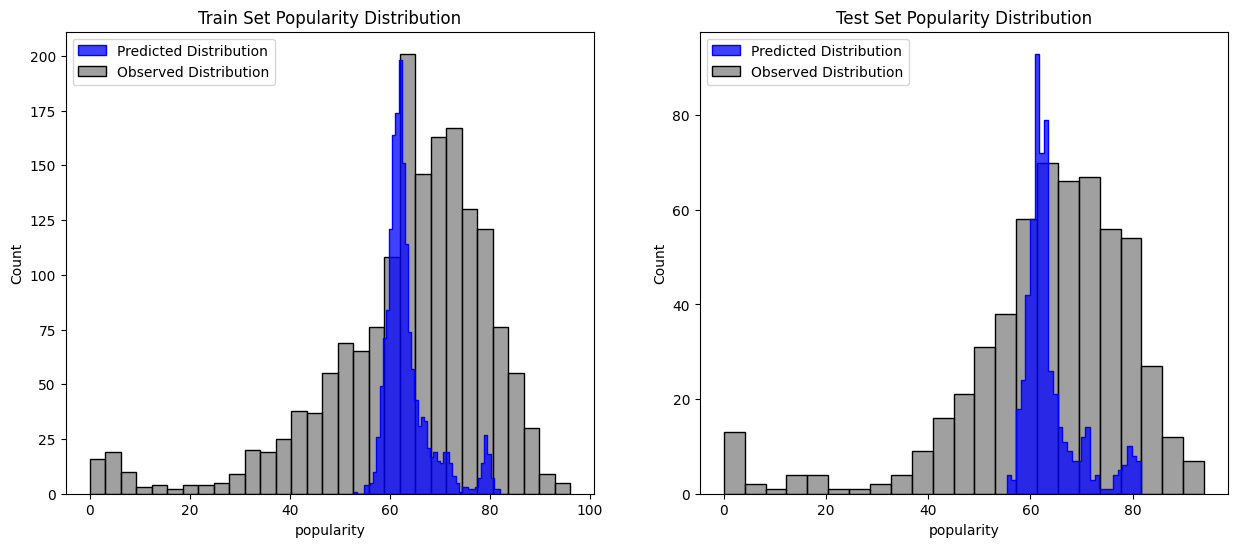

In [30]:
# Train Set Predictions
ols_train_preds = pd.DataFrame(elastic_net_best_estimator.predict(train_features_scaled), index=train_response.index, columns=["expected_popularity"])

# Test Set Predictions
ols_test_preds = pd.DataFrame(elastic_net_best_estimator.predict(test_features_scaled), index=test_response.index, columns=["expected_popularity"])

print(f"Test Set RMSE: {np.sqrt(mean_squared_error(test_response['popularity'], ols_test_preds['expected_popularity'])):.2f}")
print(f"Test Set R^2: {r2_score(test_response['popularity'], ols_test_preds['expected_popularity']):.2f}")
print(f"Test Set D^2: {elastic_net_best_estimator.score(test_features_scaled, test_response['popularity']):.2f}")

plot_train_test_dist(
    train_predictions=ols_train_preds,
    train_response=train_response,
    test_predictions=ols_test_preds,
    test_response=test_response
)

plt.show()

##### Poisson GLM

In [17]:
pglm_grid_search_params = {
    'alpha': en_grid_search_params['alpha']
}

pglm_grid_search = GridSearchCV(
    estimator=LINEAR_CANDIDATE_MODELS_MAP['poission_glm_regression'](),
    param_grid=pglm_grid_search_params,
    scoring='neg_mean_squared_log_error',
    cv=5,
    verbose=2
)

pglm_grid_search.fit(X=train_features_scaled, y=train_response['popularity'])

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END ..........................................alpha=0.1; total time=   0.1s
[CV] END ..........................................alpha=0.1; total time=   0.0s


[CV] END ..........................................alpha=0.1; total time=   0.0s
[CV] END ..........................................alpha=0.1; total time=   0.0s
[CV] END ..........................................alpha=0.1; total time=   0.0s
[CV] END ..........................alpha=0.11836734693877551; total time=   0.1s
[CV] END ..........................alpha=0.11836734693877551; total time=   0.0s
[CV] END ..........................alpha=0.11836734693877551; total time=   0.1s
[CV] END ..........................alpha=0.11836734693877551; total time=   0.0s
[CV] END ..........................alpha=0.11836734693877551; total time=   0.0s
[CV] END ..........................alpha=0.13673469387755102; total time=   0.0s
[CV] END ..........................alpha=0.13673469387755102; total time=   0.0s
[CV] END ..........................alpha=0.13673469387755102; total time=   0.0s
[CV] END ..........................alpha=0.13673469387755102; total time=   0.0s
[CV] END ...................

GridSearchCV(cv=5, estimator=PoissonRegressor(),
             param_grid={'alpha': array([0.1       , 0.11836735, 0.13673469, 0.15510204, 0.17346939,
       0.19183673, 0.21020408, 0.22857143, 0.24693878, 0.26530612,
       0.28367347, 0.30204082, 0.32040816, 0.33877551, 0.35714286,
       0.3755102 , 0.39387755, 0.4122449 , 0.43061224, 0.44897959,
       0.46734694, 0.48571429, 0.50408163, 0.52244898, 0.54081633,
       0.55918367, 0.57755102, 0.59591837, 0.61428571, 0.63265306,
       0.65102041, 0.66938776, 0.6877551 , 0.70612245, 0.7244898 ,
       0.74285714, 0.76122449, 0.77959184, 0.79795918, 0.81632653,
       0.83469388, 0.85306122, 0.87142857, 0.88979592, 0.90816327,
       0.92653061, 0.94489796, 0.96326531, 0.98163265, 1.        ])},
             scoring='neg_mean_squared_log_error', verbose=2)

In [18]:
# Display results
print(f"Best Parameters: {pglm_grid_search.best_params_}")
print(f"Best CV Score: {-pglm_grid_search.best_score_}")

# Best Estimator
pglm_best_estimator = pglm_grid_search.best_estimator_
pglm_coefs_df = pd.DataFrame({
    'feature_name': train_features.columns,
    'coefficent_value': pglm_best_estimator.coef_
})

print(pglm_coefs_df)

Best Parameters: {'alpha': 0.1}
Best CV Score: 0.29156051970126146
           feature_name  coefficent_value
0          danceability         -0.066050
1                energy         -0.133664
2              loudness          0.200175
3           speechiness         -0.168211
4          acousticness         -0.022811
5      instrumentalness          0.074176
6              liveness          0.006414
7               valence          0.042746
8                 tempo         -0.035283
9        time_signature          0.020407
10          duration_ms         -0.090427
11         release_year         -0.037034
12  mean_aggr_followers          0.318587
13               mode_0          0.009927
14               mode_1         -0.010292
15                key_0         -0.004902
16                key_1          0.013759
17                key_2          0.041685
18                key_3         -0.066354
19                key_4         -0.033914
20                key_5          0.010972
21       

Test Set RMSE: 15.72
Test Set R^2: 0.14
Test Set D^2: 0.11


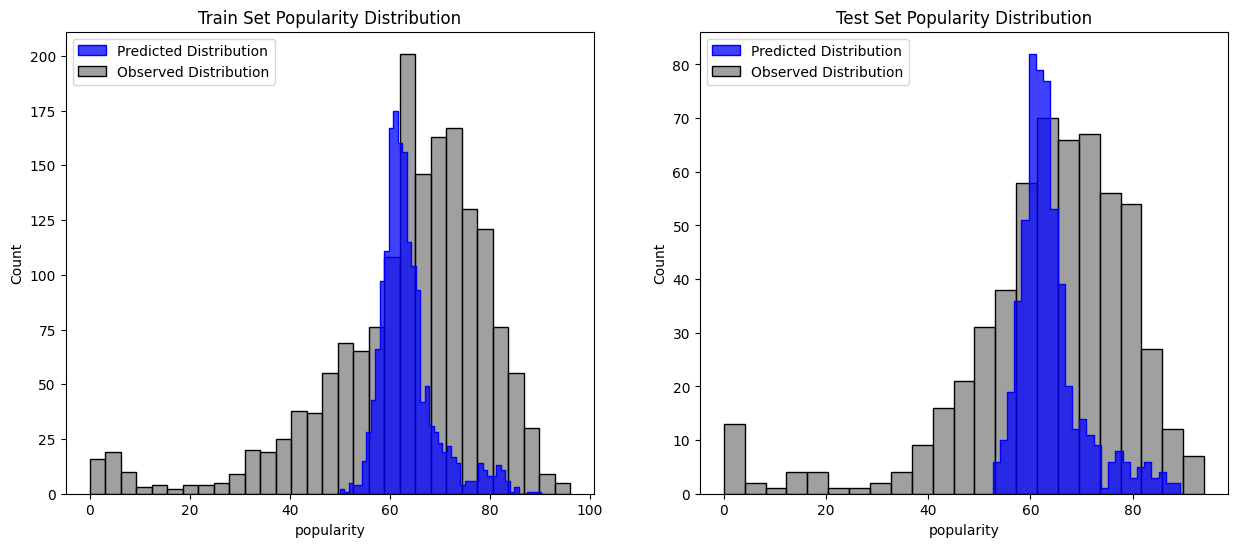

In [19]:
# Train Set Predictions
pglm_train_preds = pd.DataFrame(pglm_best_estimator.predict(train_features_scaled), index=train_response.index, columns=["expected_popularity"])

# Test Set Predictions
pglm_test_preds = pd.DataFrame(pglm_best_estimator.predict(test_features_scaled), index=test_response.index, columns=["expected_popularity"])

print(f"Test Set RMSE: {np.sqrt(mean_squared_error(test_response['popularity'], pglm_test_preds['expected_popularity'])):.2f}")
print(f"Test Set R^2: {r2_score(test_response['popularity'], pglm_test_preds['expected_popularity']):.2f}")
print(f"Test Set D^2: {pglm_best_estimator.score(test_features_scaled, test_response['popularity']):.2f}")

plot_train_test_dist(
    train_predictions=pglm_train_preds,
    train_response=train_response,
    test_predictions=pglm_test_preds,
    test_response=test_response
)

plt.show()

##### Random Forest with Poisson Criteria

Fitting 5 folds for each of 36 candidates, totalling 180 fits
[CV] END ......................max_depth=4, n_estimators=100; total time=   0.7s
[CV] END ......................max_depth=4, n_estimators=100; total time=   0.7s
[CV] END ......................max_depth=4, n_estimators=100; total time=   0.7s
[CV] END ......................max_depth=4, n_estimators=100; total time=   0.7s
[CV] END ......................max_depth=4, n_estimators=100; total time=   0.7s
[CV] END ......................max_depth=4, n_estimators=150; total time=   1.0s
[CV] END ......................max_depth=4, n_estimators=150; total time=   1.1s
[CV] END ......................max_depth=4, n_estimators=150; total time=   1.2s
[CV] END ......................max_depth=4, n_estimators=150; total time=   1.2s
[CV] END ......................max_depth=4, n_estimators=150; total time=   1.2s
[CV] END ......................max_depth=4, n_estimators=200; total time=   1.7s
[CV] END ......................max_depth=4, n_e

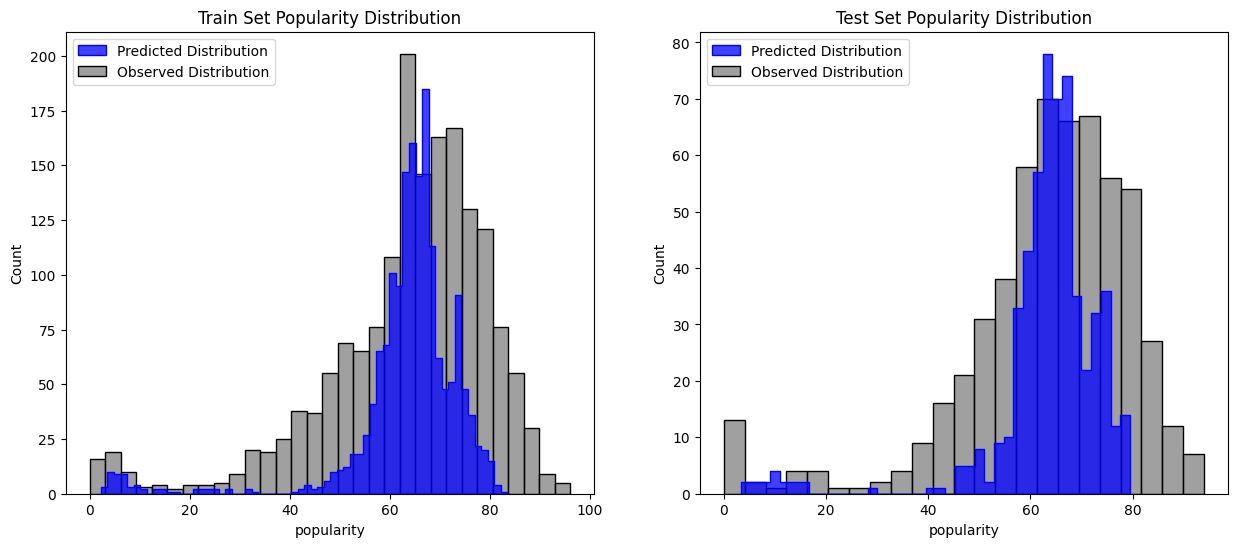

In [20]:
from sklearn.ensemble import RandomForestRegressor

rf_regressor_grid_search_params = {
    'n_estimators': range(100, 550, 50),
    'max_depth': range(4, 8)
}

rf_regressor = RandomForestRegressor(criterion='poisson')

rf_regressor_grid_search = GridSearchCV(
    estimator=rf_regressor,
    param_grid=rf_regressor_grid_search_params,
    scoring='neg_root_mean_squared_error',
    cv=5,
    verbose=2
)

rf_regressor_grid_search.fit(train_features_scaled, train_response['popularity'])

# Best model
rf_regressor_best = rf_regressor_grid_search.best_estimator_

# Train Set Predictions
rf_regressor_train_preds = pd.DataFrame(rf_regressor_best.predict(train_features_scaled), index=train_response.index, columns=["expected_popularity"])

# Test Set Predictions
rf_regressor_test_preds = pd.DataFrame(rf_regressor_best.predict(test_features_scaled), index=test_response.index, columns=["expected_popularity"])

print(f"Best Parameters: {rf_regressor_grid_search.best_params_}")
print(f"Test Set RMSE: {np.sqrt(mean_squared_error(test_response['popularity'], rf_regressor_test_preds['expected_popularity'])):.2f}")
print(f"Test Set R^2: {r2_score(test_response['popularity'], rf_regressor_test_preds['expected_popularity']):.2f}")
print(f"Test Set D^2: {rf_regressor_best.score(test_features_scaled, test_response['popularity']):.2f}")

plot_train_test_dist(
    train_predictions=rf_regressor_train_preds,
    train_response=train_response,
    test_predictions=rf_regressor_test_preds,
    test_response=test_response
)

plt.show()

##### `scikit-learn`'s Light GBM Implementation

Fitting 5 folds for each of 36 candidates, totalling 180 fits
[CV] END .....................max_features=0.4, max_iter=100; total time=   0.6s
[CV] END .....................max_features=0.4, max_iter=100; total time=   0.5s
[CV] END .....................max_features=0.4, max_iter=100; total time=   0.4s
[CV] END .....................max_features=0.4, max_iter=100; total time=   0.4s
[CV] END .....................max_features=0.4, max_iter=100; total time=   0.5s
[CV] END .....................max_features=0.4, max_iter=200; total time=   0.8s
[CV] END .....................max_features=0.4, max_iter=200; total time=   1.0s
[CV] END .....................max_features=0.4, max_iter=200; total time=   0.8s
[CV] END .....................max_features=0.4, max_iter=200; total time=   0.7s
[CV] END .....................max_features=0.4, max_iter=200; total time=   0.7s
[CV] END .....................max_features=0.4, max_iter=300; total time=   1.1s
[CV] END .....................max_features=0.4,

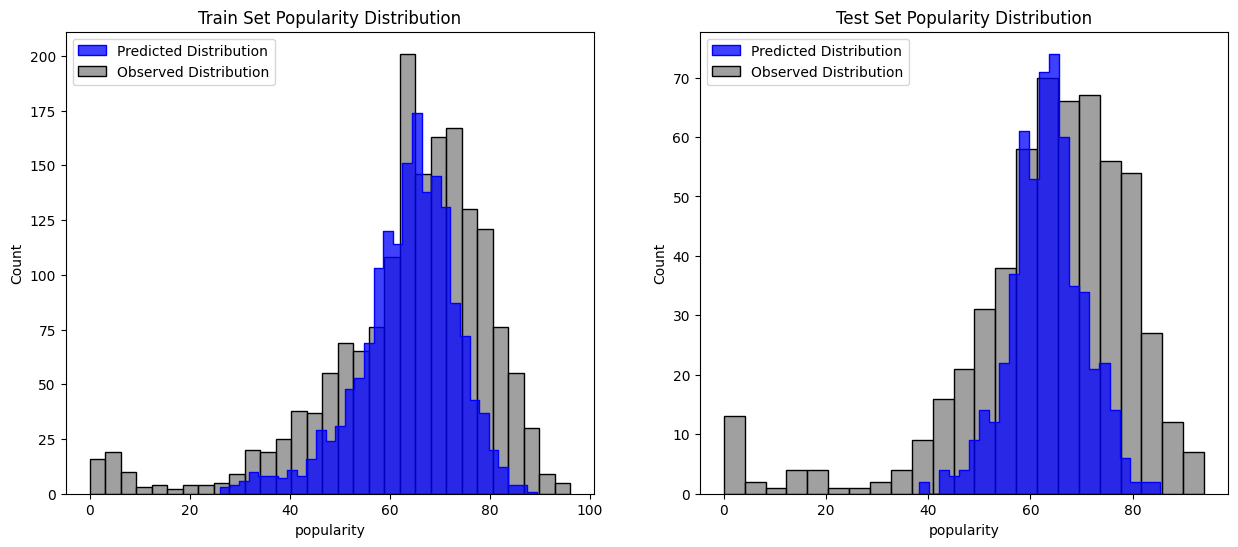

In [41]:
from sklearn.ensemble import HistGradientBoostingRegressor

hgbr_grid_search_params = {
    'max_iter': range(100, 700, 100),
    'max_features': np.linspace(0.4, 1.0, 6),
}

hgbr = HistGradientBoostingRegressor(loss='poisson')

hgbr_grid_search = GridSearchCV(
    estimator=hgbr,
    param_grid=hgbr_grid_search_params,
    scoring='neg_root_mean_squared_error',
    cv=5,
    verbose=2
)

hgbr_grid_search.fit(train_features_scaled, train_response['popularity'])

# Best model
hgbr_best = hgbr_grid_search.best_estimator_

# Train Set Predictions
hgbr_train_preds = pd.DataFrame(hgbr_best.predict(train_features_scaled), index=train_response.index, columns=["expected_popularity"])

# Test Set Predictions
hgbr_test_preds = pd.DataFrame(hgbr_best.predict(test_features_scaled), index=test_response.index, columns=["expected_popularity"])

print(f"Best Parameters: {hgbr_grid_search.best_params_}")
print(f"Test Set RMSE: {np.sqrt(mean_squared_error(test_response['popularity'], hgbr_test_preds['expected_popularity'])):.2f}")
print(f"Test Set R^2: {r2_score(test_response['popularity'], hgbr_test_preds['expected_popularity']):.2f}")
print(f"Test Set D^2: {hgbr_best.score(test_features_scaled, test_response['popularity']):.2f}")

plot_train_test_dist(
    train_predictions=hgbr_train_preds,
    train_response=train_response,
    test_predictions=hgbr_test_preds,
    test_response=test_response
)

plt.show()

In [42]:
residuals = np.abs(hgbr_train_preds['expected_popularity'] - train_response['popularity'])
ground_truth = modelling_df[modelling_df.index.isin(residuals.index)]['popularity']

residual_plot_data = pd.DataFrame({
    'residuals': residuals,
    'ground_truth_popularity': ground_truth,
}, index = residuals.index)
# sns.scatterplot(x=residual_plot_data['ground_truth_popularity'], y=residual_plot_data['residuals'])

tmp_model = HistGradientBoostingRegressor(
    loss='poisson',
    learning_rate=0.1,
    max_depth=4,
    max_iter=40,
    l2_regularization=1.0
)

tmp_model.fit(train_features_scaled, train_response['popularity'])

from sklearn.inspection import permutation_importance

res = permutation_importance(tmp_model, train_features_scaled, train_response['popularity'])

importance_df = pd.DataFrame({
    'feature': train_features.columns,
    'importance_mean': res['importances_mean'],
    'importance_std': res['importances_std'],
}).sort_values('importance_mean', ascending=False)
importance_df

,feature,importance_mean,importance_std
3,speechiness,0.099749,0.004192
8,tempo,0.073842,0.002834
2,loudness,0.056352,0.003966
1,energy,0.047213,0.003538
10,duration_ms,0.042912,0.001854
4,acousticness,0.038910,0.003702
0,danceability,0.031699,0.003491
7,valence,0.020340,0.000811
6,liveness,0.014488,0.001662
5,instrumentalness,0.011875,0.001580


In [23]:
from sklearn.cluster import KMeans

train_w_clusters = train_features.copy()

kmeans_model = KMeans(n_clusters=10)
train_w_clusters['cluster'] = kmeans_model.fit_predict(train_w_clusters)

cluster_df = pd.merge(
    left=train_w_clusters['cluster'],
    left_on=train_w_clusters.index,
    right=track_df,
    right_on=track_df.index,
    how='left'
)[['cluster', 'track_name', 'popularity', 'track_artists_name', 'track_artists_genres', 'speechiness']]
cluster_df

,cluster,track_name,popularity,track_artists_name,track_artists_genres,speechiness
0,8,Bigger Than You (feat. Drake & Quavo),55,2 Chainz|Drake|Quavo,atl hip hop|hip hop|pop rap|rap|southern hip h...,0.2710
1,3,I'm Upset,69,Drake,canadian hip hop|canadian pop|hip hop|pop rap|rap,0.3430
2,0,Heartbreaking,45,Lil Mabu,NaN,0.1690
3,5,Say Something (Featuring Drake),65,Timbaland|Drake,dance pop|pop|pop rap|canadian hip hop|canadia...,0.0911
4,7,Modern Day,57,Migos,atl hip hop|hip hop|pop rap|rap|trap,0.2790
...,...,...,...,...,...,...
1686,0,Moody,56,Sheff G,brooklyn drill|new york drill|nyc rap,0.1470
1687,5,100 (feat. Drake),53,The Game|Drake,detroit hip hop|gangster rap|hip hop|pop rap|r...,0.3550
1688,4,the ride-,62,Lil Yachty,atl hip hop|melodic rap|rap|trap,0.0661
1689,3,Thank Me Now,51,Drake,canadian hip hop|canadian pop|hip hop|pop rap|rap,0.4250


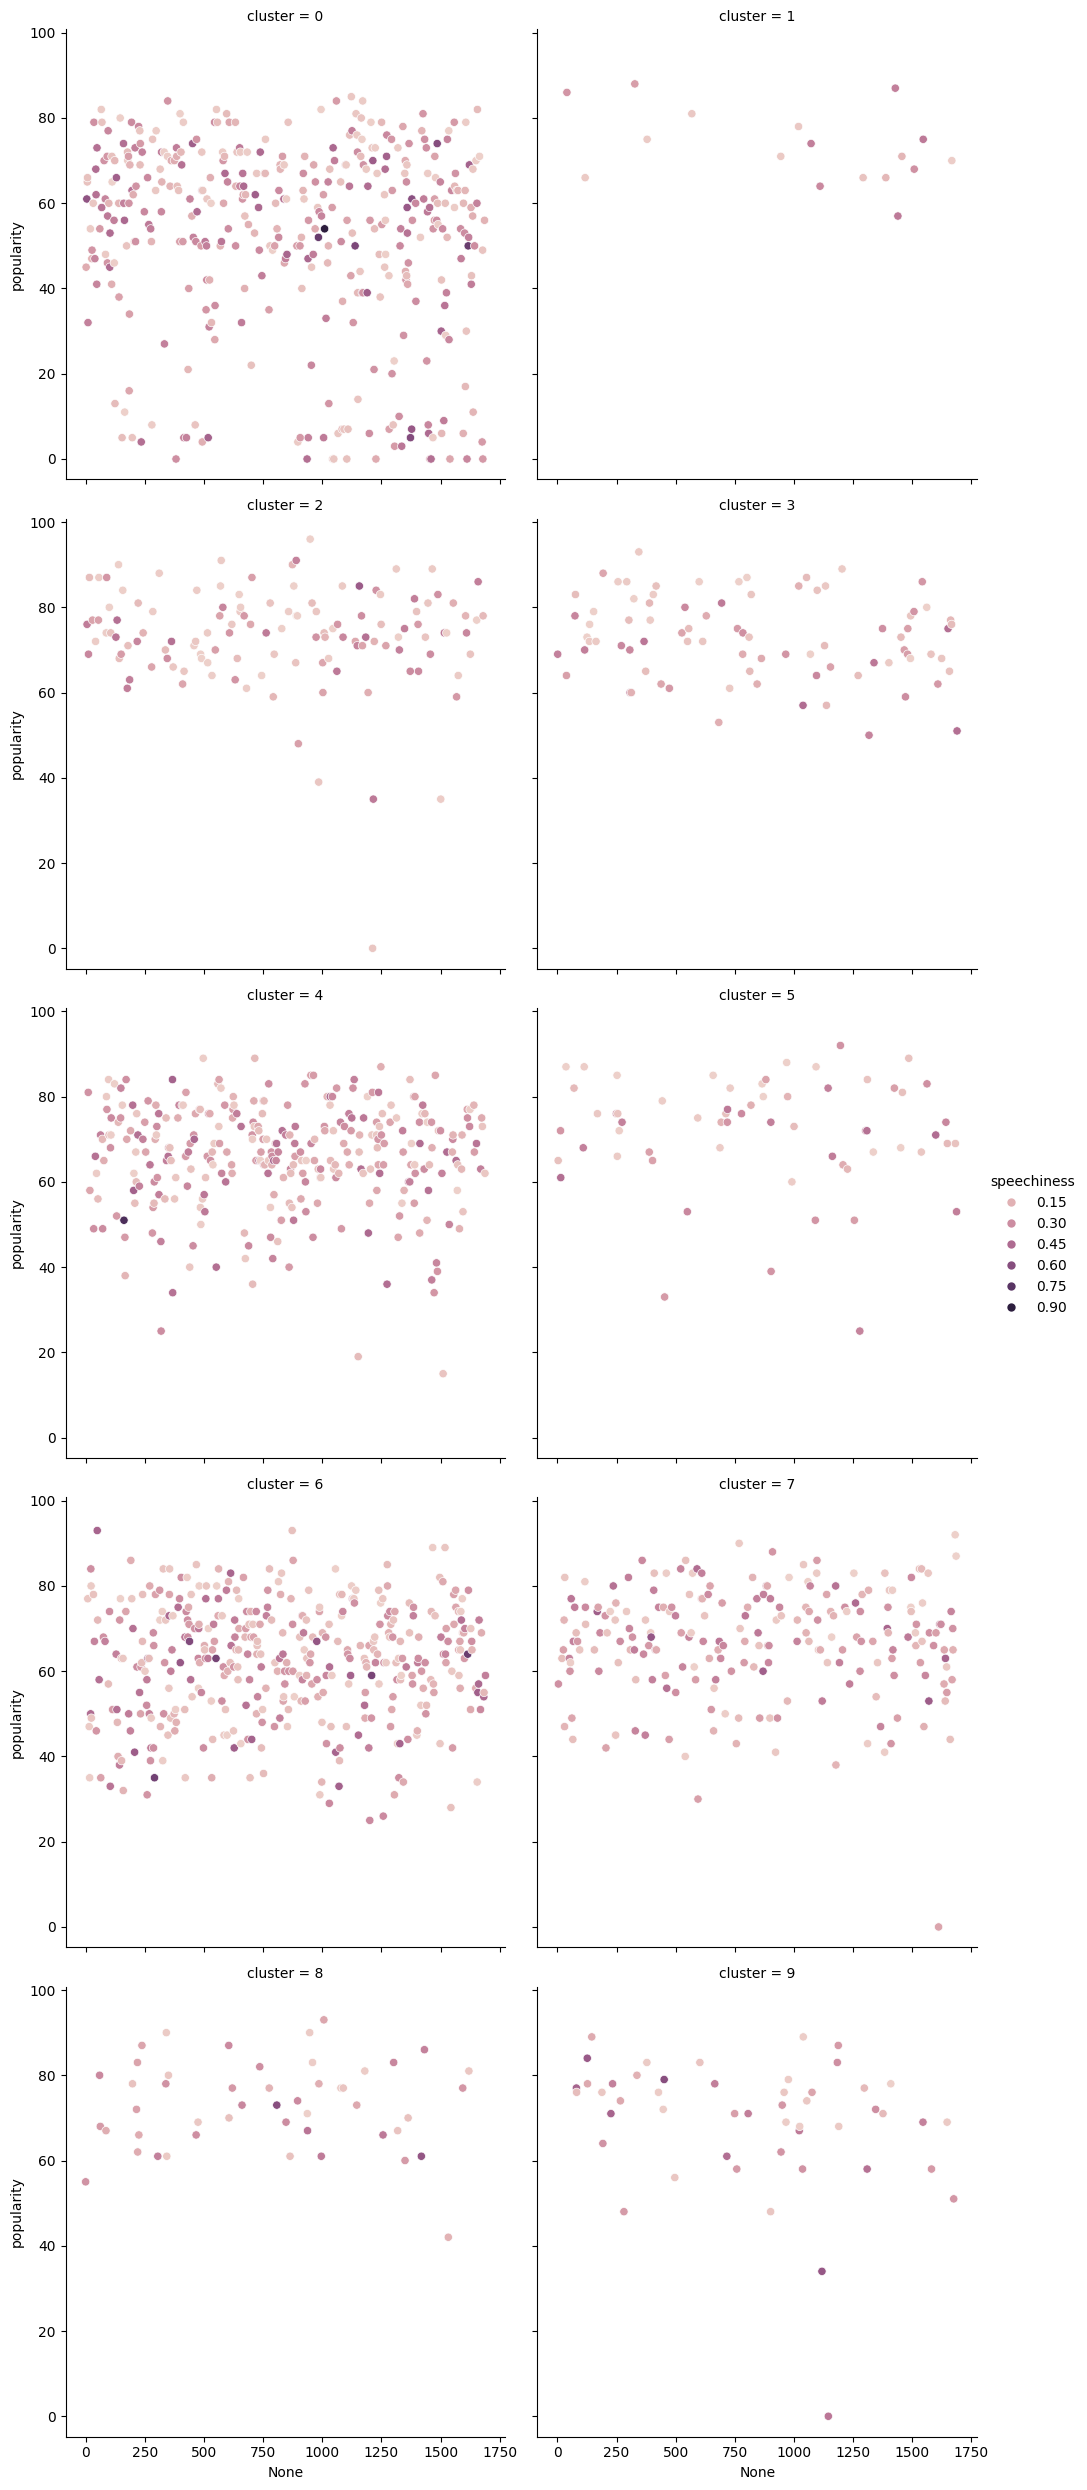

In [24]:
sns.relplot(data=cluster_df, y='popularity', x=cluster_df.index, hue='speechiness', col='cluster', col_wrap=2)

#### Linear Regression  

We'll fit an initial linear regression model as the response distribution seems roughly normal.

In [25]:
from sklearn import linear_model

# Instantiate Model Obj
lr_model = linear_model.LinearRegression()


# Fit Model to data
lr_model.fit(
    X=train_features_scaled,
    y=train_response
)

# Coefficients df
lr_coeffs_df = pd.DataFrame({
    'feature': test_features.columns,
    'value': lr_model.coef_[0]
})

# Train Set Predictions
lr_train_preds = pd.DataFrame(lr_model.predict(train_features_scaled), index=train_response.index, columns=["expected_popularity"])

# Test Set Predictions
lr_test_preds = pd.DataFrame(lr_model.predict(test_features_scaled), index=test_response.index, columns=["expected_popularity"])

##### Model Diagnostics

##### Coefficients

In [26]:
lr_coeffs_df

,feature,value
0,danceability,-4.867140
1,energy,-10.933395
2,loudness,15.312533
3,speechiness,-11.032333
4,acousticness,-1.779285
5,instrumentalness,8.781499
6,liveness,0.466604
7,valence,3.325609
8,tempo,-2.400958
9,time_signature,1.849191


##### RMSE 

In [27]:
from numpy import sqrt

print(f"Test Set RMSE: {sqrt(mean_squared_error(test_response['popularity'], lr_test_preds['expected_popularity'])):.2f}")
print(f"Test Set R^2: {r2_score(test_response['popularity'], lr_test_preds['expected_popularity']):.2f}")

Test Set RMSE: 15.63
Test Set R^2: 0.15


##### Observed vs. Predicted Popularity Test Set Plot

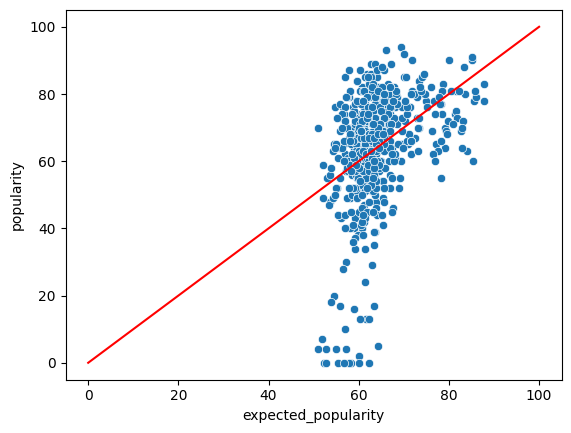

In [28]:
sns.scatterplot(
    x=lr_test_preds["expected_popularity"],
    y=test_response["popularity"]
)
plt.plot([0, 100], [0, 100], color = 'red')
plt.show()

In [29]:
from src.model_utils import plot_train_test_dist

axes = plot_train_test_dist(
    train_predictions=lr_train_preds,
    train_response=train_response,
    test_predictions=lr_test_preds,
    test_response=test_response
)

plt.show()

ModuleNotFoundError: No module named 'src.model_utils'

### Optimal Model

In [31]:
metrics_df = pd.DataFrame({
    'method': ['ElasticNet OLS', 'Poisson GLM (Ridge)', 'Random Forest (Poisson Criteria)', 'Light GBM'],
    'Test Set RMSE': [15.71, 15.72, 11.66, 11.68], 
    'Test Set R^2': [0.14, 0.14, 0.53, 0.53], 
})
metrics_df

,method,Test Set RMSE,Test Set R^2
0,ElasticNet OLS,15.71,0.14
1,Poisson GLM (Ridge),15.72,0.14
2,Random Forest (Poisson Criteria),11.66,0.53
3,Light GBM,11.68,0.53


From above, we'll select the **Light GBM** as our champion model since it has a good RMSE and decent R^2.

It is preferred in this case because it explains the variance of the `popularity` distribution much better than the Random Forest

### Model Feature Importance

Looking at the feature importance, a few insights:

- Follower count seems to be the deciding factor in popularity (87% importance), followed by `release_year` (11% importance)  

- PDP plots would help in explaining the relationship with the response  

It would be interesting to fit another model without follower information to see if the song build is predictive since a caveat here is that artistes with larger followers get more plays hence more popularity.

Doing this results in a much worse fit (RMSE of 17.23, R^2 -0.03) with minimal jumps in feature importance of song attributes

In [32]:
importance_df

,feature,importance_mean,importance_std
12,mean_aggr_followers,0.870768,0.036580
11,release_year,0.106514,0.006808
3,speechiness,0.032636,0.002199
7,valence,0.011944,0.001277
8,tempo,0.010786,0.000978
10,duration_ms,0.010082,0.000907
4,acousticness,0.008259,0.001458
1,energy,0.007610,0.000577
0,danceability,0.006376,0.000565
6,liveness,0.006059,0.000984
